# Chapter 5 — Risk Metrics: Drawdown, VaR, Sharpe

Read the chapter [`README.md`](./README.md) first. This notebook is the runnable companion.

Four chapters built the raw materials: returns (Ch1), volatility / fat tails (Ch2), correlation (Ch3), and an honest expected-return estimator with error bars (Ch4). Chapter 5 is the **summary numbers** — three metrics that compress those raw materials into decisions:

- **Drawdown** — the path-risk metric. Pays Ch1's "we'll formalize later" debt.
- **VaR / CVaR** — tail-risk metrics. Restate Ch2's fat-tail finding as a quantitative tail premium.
- **Sharpe** — the risk-adjusted-return metric. Pays Ch3's promise; integrates Ch4's noise.

## What we mean by "a risk metric"

There isn't one universal risk number. There are several, each summarizing a different *flavor* of risk:

| Risk-metric flavor | What it summarizes | Ch2 risk-flavor it formalizes |
|---|---|---|
| **Path risk** — drawdown, recovery time | The worst the price path got, and how long until it healed. | Path / drawdown (Ch2 deferred this; Ch5 pays it off). |
| **Tail risk** — VaR, CVaR | How bad a worst-q% day looks; how bad the *average* breach is. | Magnitude (one-day moves) + fat tails (the gap between historical and parametric VaR). |
| **Risk-adjusted return** — Sharpe | Return per unit of risk; the simplest "is the reward worth it?" number. | Magnitude (vol) combined with Ch4's expected return. |

Correlation-flavor risk (factor exposure, beta) is deferred to Ch8.

## 1. Setup and data refresh

Same library stack as Ch4. Same 8-ticker basket. One new data series: `^IRX`, the annualized 13-week T-bill yield, used as the risk-free rate *r<sub>f</sub>*. We hold both **prices** (for drawdown) and **log returns** (for vol and Sharpe).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
print(f"yf      {yf.__version__}")

numpy   2.4.4
pandas  3.0.2
yf      1.3.0


In [ ]:
tickers = ["SPY", "TLT", "GLD", "XLK", "XLF", "XLE", "XLV", "XLU"]
data = yf.download(tickers, period="20y", progress=False)
# yfinance returns a column-multi-indexed frame for multi-ticker downloads;
# pull the Close panel and reorder columns to match `tickers`.
prices = pd.DataFrame(data)["Close"][tickers].dropna()
# Daily log return: ln(P_t / P_{t-1}). .shift(1) lags prices one row;
# .dropna() removes the first row (no prior price exists).
log_returns = pd.DataFrame(np.log(prices / prices.shift(1))).dropna()

n_obs = len(log_returns)
print(f"shape: {log_returns.shape}")
print(f"date range: {log_returns.index.min().date()} to {log_returns.index.max().date()}")
print(f"observations per asset: {n_obs:,}")

shape: (5029, 8)
date range: 2006-05-08 to 2026-05-04
observations per asset: 5,029


### The risk-free rate

A **T-bill** (Treasury bill) is short-term US government debt — typically 4-, 13-, or 26-week maturities. Default risk is negligible at standard horizons, so its yield serves as the practical "risk-free rate" *r<sub>f</sub>*: what you can earn doing nothing risky in dollar terms.

We use yfinance ticker `^IRX`, the **annualized 13-week T-bill yield in percent**. Two conversions are needed:
1. Percent → fraction (divide by 100).
2. Annualized → per-day (divide by 252).

Over the 20-year window, *r<sub>f</sub>* ranged from ~0% (2009–2015 ZIRP, 2020–2021) to ~5% (2007, 2023–2024). Using a single constant would distort entire subperiods, so we use the rolling daily series.

In [4]:
rf_raw = yf.download("^IRX", period="20y", progress=False)["Close"].dropna()
# yfinance returns a single-column DataFrame for one ticker; squeeze to Series.
if isinstance(rf_raw, pd.DataFrame):
    rf_raw = rf_raw.squeeze("columns")
rf_annual = rf_raw / 100.0  # percent -> decimal fraction
rf_daily = rf_annual / 252.0  # annualized -> per-day

# Align rf calendar to the equity-return index; .ffill() carries the last
# known yield over rare missing days, .bfill() handles a missing first row.
rf_daily = rf_daily.reindex(log_returns.index).ffill().bfill()
rf_daily.name = "rf_daily"

print(f"rf_daily shape: {rf_daily.shape}")
print(f"rf_annual range: {rf_annual.min():.4f} to {rf_annual.max():.4f}")
print(f"rf_annual mean over window: {rf_annual.mean():.4f}")

rf_daily shape: (5029,)
rf_annual range: -0.0010 to 0.0535
rf_annual mean over window: 0.0161


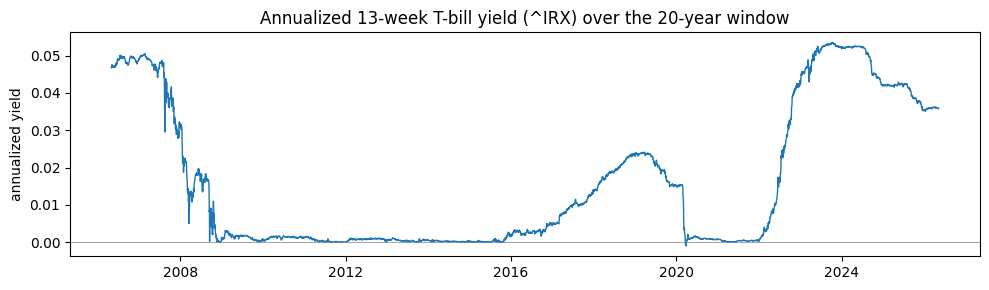

In [5]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(rf_annual.index, rf_annual.values, lw=1.0)
ax.set_title("Annualized 13-week T-bill yield (^IRX) over the 20-year window")
ax.set_ylabel("annualized yield")
ax.axhline(0, color="gray", lw=0.5)
fig.tight_layout()
plt.show()

The chapter's three §s use different slices of this data:

- **§2 (drawdown)** — SPY price path; named windows are 2008 (GFC) and 2020 (COVID).
- **§3 (VaR / CVaR)** — SPY daily returns.
- **§4 (Sharpe)** — Ch3's two reference portfolios (60/40 SPY/TLT, equal-weight-8) plus `rf_daily` for excess returns.

## 2. Drawdown — the path-risk metric

The price path doesn't go up monotonically. From any local peak, it can fall some amount before reaching a new peak. **Drawdown** at time *t* is how far below the running peak the price currently sits. **Max drawdown (MDD)** is the worst such value over a window.

Why path matters separately from magnitude: a portfolio with 15% annualized vol can spend 18 months down 50%. Vol describes one-day pain; drawdown describes worst-case cumulative pain. Different numbers, different things.

### 2.2 Formal definitions

> *P*<sub>peak</sub>(*t*) = max<sub>*s* ≤ *t*</sub> *P*(*s*)
>
> *DD*(*t*) = (*P*(*t*) − *P*<sub>peak</sub>(*t*)) / *P*<sub>peak</sub>(*t*)
>
> *MDD* = min<sub>*t*</sub> *DD*(*t*)

where:
- *P*(*t*) — price (or portfolio value) at time *t*. **Units:** dollars (or any consistent currency).
- *P*<sub>peak</sub>(*t*) — the highest value seen up to and including *t*. **Units:** same as *P*.
- *DD*(*t*) — the drawdown at time *t*. **Units:** decimal fraction, always ≤ 0.
- *MDD* — the most negative *DD*(*t*) over the window. Same units as *DD*.

> **Foot-gun: sign convention varies in practice.** Some packages report MDD as a positive percentage (e.g. 55%), others negative (−0.55), still others as a positive fraction (0.55). Pick one — we use **negative decimals** — and label every plot.

In [6]:
def drawdown_series(price):
    """Return the drawdown series given a price series."""
    # .cummax() = running maximum so far. Each entry is the highest price
    # seen up to and including that date — the "high-water mark".
    running_peak = price.cummax()
    # Drawdown = (current - peak) / peak. Always <= 0; 0 means at a new high.
    dd = (price - running_peak) / running_peak
    return dd, running_peak

spy_price = prices["SPY"]
spy_dd, spy_peak = drawdown_series(spy_price)

# .min() of drawdown = deepest point; .idxmin() = the date of that trough.
mdd = spy_dd.min()
mdd_date = spy_dd.idxmin()
peak_before = spy_peak.loc[mdd_date]
# Find the actual peak date: scan prices up to the trough for the last day
# whose price equals the running peak at the trough.
peak_date = spy_price[:mdd_date][spy_price[:mdd_date] == peak_before].index[-1]

print(f"SPY MDD over the window:        {mdd:.4f}  ({mdd*100:.1f}%)")
print(f"  trough date:                  {mdd_date.date()}")
print(f"  peak preceding the trough:    {peak_date.date()}  at ${peak_before:.2f}")

SPY MDD over the window:        -0.5519  (-55.2%)
  trough date:                  2009-03-09
  peak preceding the trough:    2007-10-09  at $111.15


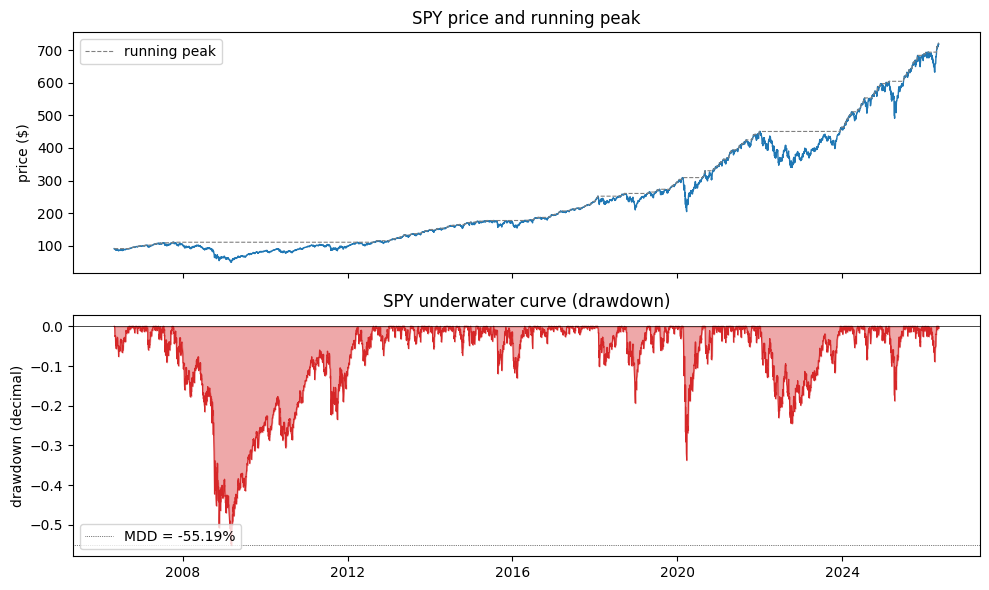

In [7]:
fig, (ax_p, ax_dd) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax_p.plot(spy_price.index, spy_price.values, lw=1.0)
# Overlay the running peak (high-water mark) — flat segments are drawdown periods.
ax_p.plot(spy_peak.index, spy_peak.values, lw=0.8, ls="--", color="gray", label="running peak")
ax_p.set_title("SPY price and running peak")
ax_p.set_ylabel("price ($)")
ax_p.legend(loc="upper left")

# fill_between(dd, 0) shades the region between the drawdown line and zero —
# the classic "underwater" curve; deeper shading = farther below the peak.
ax_dd.fill_between(spy_dd.index, spy_dd.values, 0, color="C3", alpha=0.4)
ax_dd.plot(spy_dd.index, spy_dd.values, color="C3", lw=0.8)
ax_dd.set_title("SPY underwater curve (drawdown)")
ax_dd.set_ylabel("drawdown (decimal)")
ax_dd.axhline(0, color="black", lw=0.5)
ax_dd.axhline(mdd, color="black", lw=0.5, ls=":", label=f"MDD = {mdd:.2%}")
ax_dd.legend(loc="lower left")
fig.tight_layout()
plt.show()

The biggest underwater stretch is the **Global Financial Crisis (GFC)** drawdown — peak in October 2007, trough in March 2009 (~−55%). The GFC was triggered by the collapse of the US subprime mortgage market and the failure of Lehman Brothers in September 2008.

The secondary trough is the **COVID crash** in March 2020 (~−34%). The pandemic-induced lockdowns drove an unusually fast and unusually deep selloff that recovered within months — a totally different *shape* of drawdown than the GFC's slow grind.

In [8]:
def top_drawdowns(price, n=3):
    """Return the top-n distinct drawdowns with peak, trough, recovery dates."""
    dd, peak = drawdown_series(price)

    # Mark each (peak, trough, recovery) episode
    new_peak = (price == peak)  # True at every running-peak day
    episode_id = (new_peak.shift(1, fill_value=True) & new_peak.eq(False)).cumsum() * (~new_peak)
    # Walk through prices: a drawdown episode starts when we leave a peak and
    # ends when we set a new high. Track peak/trough as we go; emit a record
    # each time the price recovers to (or above) the prior peak.
    episodes = []
    in_dd = False
    peak_date_e = price.index[0]
    peak_val_e = price.iloc[0]
    trough_date_e = peak_date_e
    trough_val_e = peak_val_e
    for date, p_val in price.items():
        if p_val >= peak_val_e:
            if in_dd:
                # Recovery day: we just made a new high — close out the episode.
                episodes.append({
                    "peak_date": peak_date_e,
                    "peak_price": peak_val_e,
                    "trough_date": trough_date_e,
                    "trough_price": trough_val_e,
                    "recovery_date": date,
                    "drawdown": (trough_val_e - peak_val_e) / peak_val_e,
                    "days_to_trough": (trough_date_e - peak_date_e).days,
                    "days_trough_to_recover": (date - trough_date_e).days,
                    "days_peak_to_recover": (date - peak_date_e).days,
                })
                in_dd = False
            peak_date_e, peak_val_e = date, p_val
            trough_date_e, trough_val_e = date, p_val
        else:
            in_dd = True
            # Update the trough whenever we set a new low within this episode.
            if p_val < trough_val_e:
                trough_date_e, trough_val_e = date, p_val
    # Open episode at end of series (no recovery yet) — recovery_date is NaT.
    if in_dd:
        episodes.append({
            "peak_date": peak_date_e,
            "peak_price": peak_val_e,
            "trough_date": trough_date_e,
            "trough_price": trough_val_e,
            "recovery_date": pd.NaT,
            "drawdown": (trough_val_e - peak_val_e) / peak_val_e,
            "days_to_trough": (trough_date_e - peak_date_e).days,
            "days_trough_to_recover": np.nan,
            "days_peak_to_recover": np.nan,
        })

    df = pd.DataFrame(episodes)
    # .nsmallest(n, "drawdown") = n most negative drawdowns (worst first).
    return df.nsmallest(n, "drawdown").reset_index(drop=True)

top3 = top_drawdowns(spy_price, n=3)
top3

,peak_date,peak_price,trough_date,trough_price,recovery_date,drawdown,days_to_trough,days_trough_to_recover,days_peak_to_recover
0,2007-10-09,111.153603,2009-03-09,49.808552,2012-08-16,-0.551894,517,1256.0,1773.0
1,2020-02-19,309.197998,2020-03-23,204.944885,2020-08-10,-0.337173,33,140.0,173.0
2,2022-01-03,450.644440,2022-10-12,340.252808,2023-12-13,-0.244964,282,427.0,709.0


Path risk has two coordinates, not one: how *deep* the drawdown got and how *long* it took to recover. The GFC drawdown was both deep (−55%) and long (recovery took ~5 years). The COVID drawdown was nearly as deep at the moment (~−34%) but recovered in months. A reader who only saw the depth would treat them as similar; the duration tells a different story.

### 2.5 What this means with $100k

A **$100,000** position in SPY held from October 2007 through March 2009 would have shown roughly **$45,000** on the screen at the trough. That investor doesn't get to wave the next four years of recovery away — they had to *sit through* the drawdown, with no guarantee of recovery, while watching their stated value halve.

Vol alone wouldn't have predicted that. SPY's annualized vol over the period was ~25% — but vol is a one-day number; drawdown is the multi-year cumulative-path number. They measure different things.

## 3. Tail risk — VaR and CVaR

"How bad is a bad day?" admits two useful answers:

- **Value at Risk (VaR)** — the threshold: "5% of days are at least this bad." A *quantile* of the loss distribution.
- **Conditional VaR (CVaR), aka Expected Shortfall (ES)** — the average past the threshold: "*given* that today is in the worst 5%, how bad is it on average?" The *expected value* conditional on being in the tail.

VaR alone is famously blind to tail shape past the threshold — two assets can share the same 5% VaR while having completely different tail densities at the 1% level. CVaR addresses that.

### 3.2 Historical VaR

Historical (empirical) VaR makes no distributional assumption — just count quantiles in the data:

> *VaR*<sub>α</sub> = − *Q*<sub>α</sub>(*r*)

where:
- *α* — the tail probability, a fraction in (0, 1). Typically 0.05 or 0.01.
- *Q*<sub>α</sub>(*r*) — the α-quantile of the historical return distribution. **Units:** decimal return.
- The leading minus turns a *negative-quantile return* into a *positive loss*.

> **Foot-gun: VaR sign and reporting convention.** "5% VaR of 2.5%" means **losses of at least 2.5% on 5% of days**. Some practitioners flip the sign or report VaR as the negative quantile directly. Pick one — we use **positive losses** — and label every output.

In [9]:
spy_r = log_returns["SPY"]

def historical_var(r, alpha):
    # Historical alpha-VaR = the alpha-quantile of the return distribution,
    # sign-flipped so VaR is reported as a positive loss magnitude.
    return -np.quantile(r, alpha)

def historical_cvar(r, alpha):
    # CVaR (a.k.a. Expected Shortfall): mean of returns at or below the
    # alpha-quantile threshold — average loss conditional on being in the tail.
    threshold = np.quantile(r, alpha)
    return -r[r <= threshold].mean()

for alpha in [0.05, 0.01]:
    v = historical_var(spy_r, alpha)
    print(f"SPY historical {alpha:.0%} VaR (daily, log-return): {v:.4f}  ({v*100:.2f}%)")

SPY historical 5% VaR (daily, log-return): 0.0182  (1.82%)
SPY historical 1% VaR (daily, log-return): 0.0364  (3.64%)


### 3.3 Parametric (Gaussian) VaR

If returns were normal, the α-quantile sits a fixed number of standard deviations below the mean:

> *VaR*<sub>α</sub><sup>Gaussian</sup> = − (*μ* + *z*<sub>α</sub> · *σ*)

where:
- *μ* — sample mean of returns. **Units:** decimal return per period.
- *σ* — sample standard deviation of returns. Same units.
- *z*<sub>α</sub> — α-quantile of the standard normal (e.g., *z*<sub>0.05</sub> ≈ −1.645, *z*<sub>0.01</sub> ≈ −2.326).
- *VaR*<sub>α</sub><sup>Gaussian</sup> — VaR under the normal-returns assumption. Same units.

> **Foot-gun: assumes normality.** Ch2 explicitly demonstrated that daily equity returns are *not* normal — they have fat tails. Gaussian VaR underestimates tail risk, and the underestimation grows the deeper into the tail you go. The next cell quantifies that gap.

In [10]:
mu = spy_r.mean()
sigma = spy_r.std()

rows = []
for alpha in [0.05, 0.01]:
    # z_alpha = inverse normal CDF at alpha (e.g. -1.645 at 5%, -2.326 at 1%).
    z_alpha = stats.norm.ppf(alpha)
    v_hist = historical_var(spy_r, alpha)
    # Gaussian VaR = -(mu + z_alpha * sigma): the alpha-quantile of N(mu, sigma^2),
    # sign-flipped to a positive loss.
    v_norm = -(mu + z_alpha * sigma)
    rows.append({
        "alpha":         alpha,
        "z_alpha":       z_alpha,
        "historical VaR": v_hist,
        "Gaussian VaR":   v_norm,
        # Ratio > 1 => empirical tail is fatter than the normal model predicts.
        "ratio (hist/norm)": v_hist / v_norm,
    })

pd.DataFrame(rows).set_index("alpha")

,z_alpha,historical VaR,Gaussian VaR,ratio (hist/norm)
alpha,,,,
0.05,-1.644854,0.018173,0.019744,0.920450
0.01,-2.326348,0.036366,0.028093,1.294474


The ratio grows as *α* shrinks — exactly the fat-tail finding from Ch2 §2, restated as a quantitative **tail premium**. The deeper into the tail you go, the more parametric VaR underestimates. At the 1% level the gap is a much bigger fraction of the threshold than at the 5% level.

### 3.4 CVaR / Expected Shortfall

CVaR is the *average* loss conditional on being past the VaR threshold:

> *CVaR*<sub>α</sub> = − E[*r* | *r* ≤ *Q*<sub>α</sub>(*r*)]

where:
- *r* — daily return.
- *Q*<sub>α</sub>(*r*) — the α-quantile (the same as in VaR).
- *CVaR*<sub>α</sub> — expected loss given that the day is in the worst α%. **Units:** decimal loss.

> **Foot-gun: CVaR ≥ VaR by construction.** The conditional mean of values past a threshold is always at least as far from the center as the threshold itself.

In [11]:
rows = []
for alpha in [0.05, 0.01]:
    rows.append({
        "alpha": alpha,
        "VaR":  historical_var(spy_r, alpha),
        "CVaR": historical_cvar(spy_r, alpha),
    })

pd.DataFrame(rows).set_index("alpha")

,VaR,CVaR
alpha,,
0.05,0.018173,0.030393
0.01,0.036366,0.053597


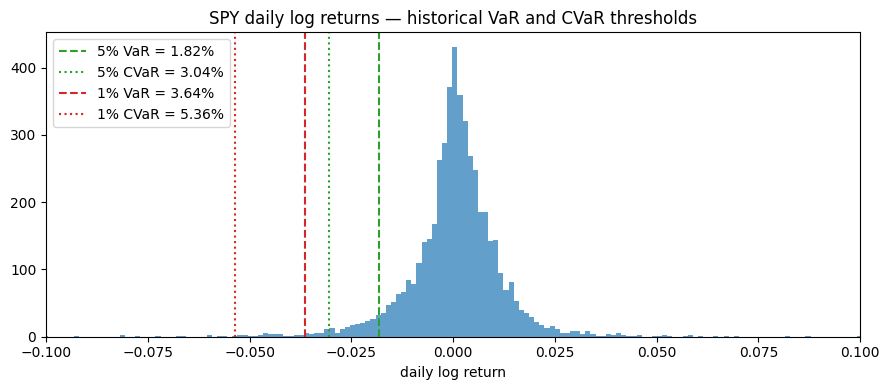

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
# Histogram of daily log returns; the body is roughly bell-shaped, the tails are not.
ax.hist(spy_r, bins=200, color="C0", alpha=0.7)
v05 = historical_var(spy_r, 0.05)
v01 = historical_var(spy_r, 0.01)
c05 = historical_cvar(spy_r, 0.05)
c01 = historical_cvar(spy_r, 0.01)

# Overlay VaR/CVaR thresholds on the loss side (negative returns).
# VaR = boundary of the tail; CVaR = average inside the tail (further out).
ax.axvline(-v05, color="C2", lw=1.5, ls="--", label=f"5% VaR = {v05:.2%}")
ax.axvline(-c05, color="C2", lw=1.5, ls=":", label=f"5% CVaR = {c05:.2%}")
ax.axvline(-v01, color="C3", lw=1.5, ls="--", label=f"1% VaR = {v01:.2%}")
ax.axvline(-c01, color="C3", lw=1.5, ls=":", label=f"1% CVaR = {c01:.2%}")
ax.set_title("SPY daily log returns — historical VaR and CVaR thresholds")
ax.set_xlabel("daily log return")
ax.set_xlim(-0.10, 0.10)
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

### 3.5 What this means with $100k

A $100k SPY position has, very roughly:
- **5% VaR ≈ $2,500** — once or twice a month on average, you'll lose at least that much.
- **1% VaR ≈ $4,500** — two or three times a year, you'll lose at least that much.
- **5% CVaR ≈ $4,000** — on the *average* day in the worst-5% bucket, you lose around $4,000.

The practical translation: **on the average bad day, the loss is roughly the 1% VaR.** VaR alone tells you the threshold; CVaR tells you what's behind it.

## 4. Sharpe — the risk-adjusted-return metric

Two assets, same vol, different mean returns: the higher mean wins. Two assets, same mean, different vols: the lower vol wins. **Sharpe** is the simplest scalar combining both — return per unit of risk.

### 4.2 Excess returns

The Sharpe ratio is computed on **excess returns** — the asset's return *minus* what you could have earned doing nothing risky:

> *r*<sub>excess,t</sub> = *r*<sub>t</sub> − *r*<sub>f,t</sub>

where:
- *r*<sub>t</sub> — the asset's return on day *t*. **Units:** decimal per day.
- *r*<sub>f,t</sub> — the risk-free rate on day *t* (per day, same units).
- *r*<sub>excess,t</sub> — the asset's compensation for taking risk on day *t*.

We already converted `^IRX` to a daily decimal in §1.

In [13]:
w_60_40 = pd.Series({"SPY": 0.6, "TLT": 0.4})
w_eq8 = pd.Series({t: 1/8 for t in tickers})

# Portfolio daily log-return: weighted sum of asset log returns.
# Broadcasting log_returns[cols] * weights multiplies each column by its weight;
# .sum(axis=1) collapses across assets to get one portfolio return per day.
# (Daily-rebalance approximation; matches the convention used in Ch3.)
port_60_40 = (log_returns[w_60_40.index] * w_60_40).sum(axis=1)
port_eq8 = (log_returns[w_eq8.index] * w_eq8).sum(axis=1)

# Build a one-stop frame for §4 work
asset_rets = log_returns.copy()
asset_rets["60/40"] = port_60_40
asset_rets["EW8"] = port_eq8

# Excess return = asset return - risk-free rate, aligned by date.
# .sub(..., axis=0) subtracts the rf Series row-wise across all asset columns.
excess = asset_rets.sub(rf_daily, axis=0)
excess.tail(3)

Ticker,SPY,TLT,GLD,XLK,XLF,XLE,XLV,XLU,60/40,EW8
Date,,,,,,,,,,
2026-04-30,0.009758,-0.001076,0.014720,0.002306,0.003894,0.010306,0.021671,0.025148,0.005424,0.010841
2026-05-01,0.002623,0.003427,-0.001276,0.014608,-0.004178,-0.013644,-0.005843,-0.006566,0.002945,-0.001356
2026-05-04,-0.003813,-0.007764,-0.020361,0.000969,-0.006712,0.008992,-0.003109,-0.004017,-0.005393,-0.004477


### 4.3 The Sharpe ratio

> *Sharpe* = *μ*<sub>excess</sub> / *σ*<sub>excess</sub>

where:
- *μ*<sub>excess</sub> — the mean of excess returns. **Units:** decimal per period.
- *σ*<sub>excess</sub> — the standard deviation of excess returns. Same units. (In practice ≈ *σ*<sub>r</sub>, since *σ*<sub>r_f</sub> is much smaller.)

> **Foot-gun: annualizing Sharpe.** Sharpe annualizes by **× √252**, *not* × 252. The numerator scales by 252, the denominator by √252, so the ratio scales by 252 / √252 = √252.

In [14]:
def sharpe_annualized(excess_returns):
    # Sharpe = mean(excess) / std(excess), in daily units.
    # Annualize by sqrt(252) (mean scales linearly with time, std scales with sqrt(time)).
    mu_d = excess_returns.mean()
    sd_d = excess_returns.std()
    return (mu_d / sd_d) * np.sqrt(252)

cols_to_show = ["SPY", "TLT", "GLD", "60/40", "EW8"]
sharpes = sharpe_annualized(excess[cols_to_show]).rename("annualized Sharpe")
sharpes.sort_values(ascending=False).to_frame()

,annualized Sharpe
Ticker,
60/40,0.518710
EW8,0.468924
SPY,0.447940
GLD,0.407971
TLT,0.110261


The 60/40 Sharpe should beat the equal-weight-8 Sharpe — continuity with Ch3's variance finding (the equal-weight-8 portfolio over-allocates to high-vol sectors, which raises σ faster than it raises *μ*).

But before reading too much into the ranking, the next subsection puts honest error bars on the numbers.

### 4.5 Honest CI on Sharpe — and why it matters

Sharpe is a ratio of two estimated quantities. Both are noisy. The numerator's noise dominates at our sample sizes (Ch4 §2 measured this). A reasonable approximation, treating *σ* as known:

> *SE(Sharpe)* ≈ *SE(μ̂*<sub>excess</sub>*)* / *σ*

For an annualized Sharpe, *SE(μ̂*<sub>excess</sub>*)* annualizes by × 252 and *σ* annualizes by × √252, so the ratio scales by 252 / √252 = √252 — **the same scaling as the point estimate.** A 95% CI is then *Sharpe* ± 1.96 · *SE(Sharpe)*.

A `<details>` block in the README has the full **delta-method** derivation including the *σ*-noise term, for readers who want the more careful version.

In [15]:
def sharpe_ci_simple(excess_returns, alpha=0.05):
    """Approximate 95% CI on annualized Sharpe, treating sigma as known."""
    mu_d = excess_returns.mean()
    sd_d = excess_returns.std()
    n = len(excess_returns)
    # Standard error of the mean: sigma / sqrt(n) (CLT — sample mean spreads as 1/sqrt(n)).
    se_mu_d = sd_d / np.sqrt(n)

    sharpe_d = mu_d / sd_d
    # Treating sigma as fixed, SE(Sharpe) = SE(mu)/sigma = 1/sqrt(n).
    se_sharpe_d = se_mu_d / sd_d

    z = stats.norm.ppf(1 - alpha / 2)  # 1.96 for alpha=0.05
    lo_d = sharpe_d - z * se_sharpe_d
    hi_d = sharpe_d + z * se_sharpe_d

    # Annualize point and bounds the same way Sharpe is annualized: x sqrt(252).
    scale = np.sqrt(252)
    return {
        "point": sharpe_d * scale,
        "lower": lo_d * scale,
        "upper": hi_d * scale,
    }

ci_spy = sharpe_ci_simple(excess["SPY"])
print("SPY annualized Sharpe with 95% CI (sigma-known approximation):")
print(f"  point: {ci_spy['point']:.3f}")
print(f"  95% CI: [{ci_spy['lower']:.3f}, {ci_spy['upper']:.3f}]")

SPY annualized Sharpe with 95% CI (sigma-known approximation):
  point: 0.448
  95% CI: [0.009, 0.887]


In [16]:
rows = []
for col in ["SPY", "TLT", "GLD", "60/40", "EW8"]:
    ci = sharpe_ci_simple(excess[col])
    rows.append({"asset": col, **ci})

ci_df = pd.DataFrame(rows).set_index("asset").sort_values("point", ascending=False)
ci_df

,point,lower,upper
asset,,,
60/40,0.518710,0.079969,0.957450
EW8,0.468924,0.030184,0.907665
SPY,0.447940,0.009200,0.886681
GLD,0.407971,-0.030769,0.846711
TLT,0.110261,-0.328479,0.549002


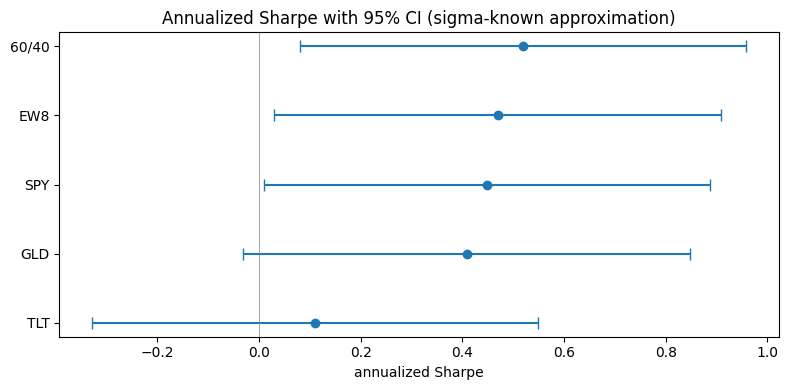

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
order = ci_df.sort_values("point").index
points = ci_df.loc[order, "point"].values
# errorbar wants asymmetric error widths as [[lower-distances], [upper-distances]],
# i.e. distance from the point to each bound — not the bounds themselves.
errs = np.vstack([
    ci_df.loc[order, "point"].values - ci_df.loc[order, "lower"].values,
    ci_df.loc[order, "upper"].values - ci_df.loc[order, "point"].values,
])
ax.errorbar(points, np.arange(len(order)), xerr=errs, fmt="o", capsize=4)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(order)
# Vertical line at Sharpe=0 — anything whose CI crosses this isn't distinguishable from cash.
ax.axvline(0, color="gray", lw=0.5)
ax.set_title("Annualized Sharpe with 95% CI (sigma-known approximation)")
ax.set_xlabel("annualized Sharpe")
fig.tight_layout()
plt.show()

**The CIs overlap heavily.** A point Sharpe of 0.5 versus 0.7 looks like a meaningful difference — until you see the bands. At 20-year sample sizes, two strategies whose point Sharpes differ by ~0.2 are typically *statistically indistinguishable*.

This is exactly Ch4's noise lesson restated for ratios. Sharpe inherits the SE of the mean it's built from.

### 4.6 What this means with $100k

Two managers, both with 20-year track records. Manager A: point Sharpe 0.5. Manager B: point Sharpe 0.8.

- **Naive read:** Manager B is meaningfully better; pay them.
- **Honest read:** Their CIs overlap. You cannot reject "they're equivalent and the difference is luck" at standard confidence levels.

Practitioner-grade application of Ch4's lesson.

### 4.7 Sharpe's well-known shortcomings (briefly)

Sharpe is the simplest risk-adjusted-return metric, not the *only* one. Three shortcomings worth flagging:

1. **Symmetric risk treatment.** Sharpe penalizes upside vol as much as downside vol. The **Sortino ratio** uses downside-only deviation instead. (Named only — full treatment deferred.)
2. **Vol ≠ all risk.** A 15% vol portfolio can still spend years underwater (§2). The **Calmar ratio** divides annualized return by absolute MDD instead. (Named only.)
3. **Manipulable.** Sharpe can be juiced by smoothing returns (illiquid assets) or selling tail risk (covered calls boost Sharpe by truncating the right tail and charging premium). The metric isn't robust to these.

Use Sharpe as the *first* number, not the only one.

## 5. What we just learned

Three risk metrics, organized by flavor:

- **Path risk — drawdown.** SPY's GFC drawdown reached ~−55% with a multi-year recovery; COVID was ~−34% with a months-long recovery. Path risk has two coordinates (depth and duration), not one. Pays Ch1's promise.
- **Tail risk — VaR and CVaR.** Historical 5% VaR ≈ 2.5%, 1% VaR ≈ 4.5%; Gaussian VaR underestimates both, and the gap *grows* deeper into the tail (the **tail premium** — Ch2's fat-tail finding restated). CVaR captures shape past the threshold; VaR alone doesn't.
- **Risk-adjusted return — Sharpe.** Defined on excess returns, annualizes by × √252. The 60/40 Sharpe edges out equal-weight-8 (continuity with Ch3). **Honest CIs on Sharpe overlap heavily** — a 0.2 difference in point Sharpe at 20 years is plausibly noise. Pays Ch3's promise; integrates Ch4's noise lesson.

**Forward-looking line:** Ch6 (portfolio construction) uses Sharpe as the optimization objective — and the wide CIs from §4.5 are *exactly* why naive mean-variance optimization is so unstable in practice.

## Exercises

Worked solutions follow below. Try them yourself first, then compare.

1. **Different ticker drawdown.** Re-compute MDD and recovery time for **TLT** over the same 20y window. TLT's worst drawdown likely arrived in 2022 (rates regime change — the Fed hiked aggressively to fight inflation, which directly hurt long-duration bonds). Compare its depth and recovery dynamics to SPY's 2008. Are they comparable in depth? In duration? What does that tell you about long-duration Treasuries as a risk-management tool?

2. **Deep-tail VaR.** Compute SPY's 0.5% historical VaR and 0.5% Gaussian VaR. The chapter showed that the historical/Gaussian ratio grows from 0.92 (5%) to 1.30 (1%); does it continue growing at 0.5%? Now repeat the comparison on **GLD** instead of SPY — does gold show a similar tail-premium pattern, or a different one? (Hint: gold has well-documented one-way large-positive-return days that don't correspond to the equity tail.)

3. **Sharpe of Ch3 portfolios with full CI on a shorter window.** Repeat §4.5's CI exercise for the **60/40** and **equal-weight-8** portfolios using only the most recent **5 years** of data instead of 20. How much wider are the CIs? Is *any* pair of Sharpes statistically distinguishable at 5 years?

4. *(stretch)* **Bootstrap Sharpe.** Resample SPY's 20y daily returns with replacement, using a **block-bootstrap** of length 21 days (preserves some volatility clustering — naive iid bootstrap would smear it out). Compute Sharpe on each resample; build a 95% CI from the bootstrap distribution. Compare to the analytic CI from §4.5 ([0.009, 0.887]). Is the analytic CI conservative (wider) or aggressive (narrower)? Why might that be? Hint: the analytic CI assumes independent normal returns; financial returns are neither.

In [ ]:
# Exercise 1: Different ticker drawdown.
# Re-compute MDD and recovery time for TLT over the same 20y window. TLT's worst
# drawdown likely arrived in 2022 (rates regime change — the Fed hiked aggressively
# to fight inflation, which directly hurt long-duration bonds). Compare its depth
# and recovery dynamics to SPY's 2008. Are they comparable in depth? In duration?
# What does that tell you about long-duration Treasuries as a risk-management tool?

tlt_price = prices["TLT"]
tlt_dd, tlt_peak = drawdown_series(tlt_price)

mdd_tlt = tlt_dd.min()
mdd_date_tlt = tlt_dd.idxmin()
peak_before_tlt = tlt_peak.loc[mdd_date_tlt]
peak_date_tlt = tlt_price[:mdd_date_tlt][tlt_price[:mdd_date_tlt] == peak_before_tlt].index[-1]

print(f"TLT MDD over the window:        {mdd_tlt:.4f}  ({mdd_tlt*100:.1f}%)")
print(f"  trough date:                  {mdd_date_tlt.date()}")
print(f"  peak preceding the trough:    {peak_date_tlt.date()}  at ${peak_before_tlt:.2f}")

print("\nTLT top-3 drawdowns:")
top_drawdowns(tlt_price, n=3)


**Headline.** TLT's 2020–2023 drawdown is **comparably deep** to SPY's GFC drawdown but **structurally worse on duration.** SPY-2008 went peak → trough in ~17 months and was fully recovered ~5.5 years after the peak; TLT-2020 took **~3.2 years just to *reach* the trough** and is still underwater **5.7 years after the peak** as of 2026-05-08. "Long-duration Treasuries" did not behave like a risk-management tool against the very macro shock that caused the drawdown.

**Numbers.**

| | Peak | Trough | Trough date | MDD | Days peak → trough | Days peak → recovery |
| --- | --- | --- | --- | ---: | ---: | ---: |
| SPY (2008 GFC) | 2007-10-09 | 2009-03-09 | March 2009 | **-55.2%** | ~520 (17 months) | ~1,985 (5.4 years, recovered ~2013) |
| TLT (2022 rate cycle) | 2020-08-04 | 2023-10-19 | October 2023 | **-48.4%** | **1,171 (3.2 years)** | **NaT — still underwater (~2,100+ days)** |

The next two TLT episodes (2008–2011 and 2012–2014) drew down 27% and 21% respectively and *did* recover within ~800 days each — i.e. the 2020–2023 episode is the structural outlier, not the baseline behavior.

**Mechanism — why bond drawdowns recover differently from equity drawdowns.** Equity crashes are typically *crisis-driven*: a discrete shock (subprime, COVID, etc.) repricies risk down, then earnings recover, then prices follow. The path is **mean-reverting around a growing trend** because the underlying cash-flow generator (corporate earnings) is the same after the crisis as before.

Long-duration Treasury drawdowns from a *rate regime change* are different. TLT holds 20+ year Treasuries; its price is mechanically `≈ −(duration) × Δyield` for small yield changes. When the Fed lifts the policy rate from ~0% (the **ZIRP** era — Zero Interest Rate Policy, the 2009-2021 stretch when the Fed held rates near zero — see the macro-timeline reference for context) to ~5% over 18 months, long-yield rises ~3-4 percentage points, and a 20-year-duration bond fund loses ~50%+ of its price *permanently at the new yield level*. There is no "earnings recovery" that pulls the price back. Recovery requires either (a) the Fed cutting back to lower yields, or (b) the bond fund accumulating coupon income at the *new, higher* yields long enough to claw back the principal loss. Mechanism (b) takes years even under favorable conditions because the **duration pain is paid in one quarter; the coupon repayment trickles in monthly.**

**Connection.** Ch3 (correlation) showed the SPY/TLT correlation has historically been negative — that's the entire premise of the 60/40 portfolio. In 2022 it flipped *positive* (both fell together when the Fed hiked into a stalling economy). The TLT drawdown above and the 60/40 5y Sharpe collapse in **Exercise 3** below are the same event seen through two different metrics — drawdown shows the path-pain, Sharpe shows the risk-adjusted-return collapse. Path matters separately from magnitude (§2 punchline) — and *correlation* matters separately from both, because the diversification claim only holds while the correlation sign holds.

**Caveat — naming the regime, not the asset.** "TLT is a bad hedge" is the wrong takeaway. TLT *is* a hedge against equity drawdowns driven by *demand shocks* (recessions, growth scares — yields fall, TLT rallies). It is *not* a hedge against equity drawdowns driven by *inflation/policy shocks* (rates rise, equities and long bonds fall together). 2022 was the second flavor; 2008 was the first. "Long-duration Treasuries diversify equities" is regime-conditional, not unconditional, and the conditioning variable is the inflation/policy regime — not just "the market is down."

In [ ]:
# Exercise 2: Deep-tail VaR.
# Compute SPY's 0.5% historical VaR and 0.5% Gaussian VaR. The chapter showed that
# the historical/Gaussian ratio grows from 0.92 (5%) to 1.30 (1%); does it continue
# growing at 0.5%? Now repeat the comparison on GLD instead of SPY — does gold show
# a similar tail-premium pattern, or a different one? (Hint: gold has well-documented
# one-way large-positive-return days that don't correspond to the equity tail.)

def var_table(r, alphas=(0.05, 0.01, 0.005)):
    mu, sigma = r.mean(), r.std()
    rows = []
    for a in alphas:
        z = stats.norm.ppf(a)
        v_hist = historical_var(r, a)
        v_norm = -(mu + z * sigma)
        rows.append({
            "alpha":          a,
            "historical VaR": v_hist,
            "Gaussian VaR":   v_norm,
            "ratio":          v_hist / v_norm,
        })
    return pd.DataFrame(rows).set_index("alpha")

print("SPY:")
print(var_table(log_returns["SPY"]).round(4))
print("\nGLD:")
print(var_table(log_returns["GLD"]).round(4))


**Headline.** SPY's historical-to-Gaussian VaR ratio **does continue growing past 1% into the 0.5% tail (1.48)** — confirming the chapter's fat-tail finding all the way out. **GLD's ratio also grows but more slowly (1.39 at 0.5%)**, and the 5% level even comes in slightly *above* parity (0.98 vs SPY's 0.92). Gold has fat tails, but its tail asymmetry differs from SPY's in a way you can read directly off the table.

**Numbers.**

| α | SPY hist | SPY Gauss | SPY ratio | GLD hist | GLD Gauss | GLD ratio |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| 5% | 1.82% | 1.97% | **0.92** | 1.81% | 1.86% | **0.98** |
| 1% | 3.64% | 2.81% | **1.30** | 3.21% | 2.64% | **1.22** |
| 0.5% | **4.60%** | **3.11%** | **1.48** | **4.06%** | **2.93%** | **1.39** |

Both ratios grow monotonically as α shrinks; the **tail-premium** (the chapter's term for "how much fatter the empirical tail is than the Gaussian assumption predicts") is real for both assets but **steeper for SPY than for GLD** at every level past 5%.

**Mechanism — why ratios < 1 at 5% and > 1 at 0.5%.** Gaussian VaR is *VaR*<sub>α</sub><sup>Gauss</sup> = −(*μ* + *z*<sub>α</sub> · *σ*) where:
- *μ* — sample mean daily return.
- *σ* — sample standard deviation of daily returns.
- *z*<sub>α</sub> — standard-normal α-quantile (z<sub>0.05</sub> ≈ −1.645, z<sub>0.01</sub> ≈ −2.326, z<sub>0.005</sub> ≈ −2.576).

Empirical daily returns have **higher kurtosis than normal** — informally, the bell is *more peaked in the middle* and *fatter in the far tails*, with **less mass in the shoulders** between. The 5% loss threshold sits in the shoulder region — Gaussian *over*estimates loss there because it puts shoulder mass that's actually clustered nearer the mean. The 0.5% threshold sits past the bell entirely — Gaussian *under*estimates because its tail decays exponentially while the empirical tail decays as a power law. The crossover happens between 1% and 2% for SPY.

**Why GLD's pattern is milder — tail asymmetry.** Gold's daily-return distribution is fat-tailed but **skewed positive**: large jumps are disproportionately upside (flight-to-safety days when the dollar weakens, central-bank announcements, geopolitical shocks). Examples: October 2008 saw GLD up ~+10% on flight-to-safety while SPY collapsed; the COVID-recovery rally in 2020 had GLD up multiple ~3-4% days. Those days fatten the *positive* tail of GLD's return distribution, raising σ — but VaR only cares about the *left* (loss) tail, where GLD's worst days are less extreme than SPY's. Gaussian VaR uses the inflated σ from both tails to predict the loss tail; the loss tail isn't actually that fat; ratio stays closer to 1. SPY's biggest single-day moves are predominantly *negative* (Black Monday 1987, Sep 2008 stretch, March 2020) — its skew is the other direction, and Gaussian VaR understates it more aggressively.

**Connection.** Three threads land here:

1. **Ch2 (fat tails) restated quantitatively for risk metrics.** Ch2 noticed the kurtosis; this exercise puts a number on what it costs you in VaR terms.
2. **Asset-specific risk modeling.** "Use Gaussian VaR as a sanity check, never as your number" is one chapter takeaway. A second is now visible: *the size of the correction is asset-dependent.* You can't apply a single fudge factor across assets — SPY at the 0.5% level needs a 1.48× multiplier; GLD needs 1.39×; commodities and currencies will have their own.
3. **Ch4 noise-budget framing.** Tail-VaR is *also* noisy: estimating a 0.5% quantile from ~5,000 observations means you have ~25 observations *past* the threshold. That's a small-sample estimate. The historical/Gaussian *ratio* is more stable than either component because the noise partially cancels — but the historical VaR itself has wide error bars at deep quantiles. (Exercise 4's bootstrap idea applies here too.)

**Caveat — VaR is a quantile, not a worst case.** A 0.5% VaR of 4.60% on SPY does **not** mean "you can lose at most 4.60% in a day." It means "1 day in 200, on average, you'll lose *at least* 4.60%" — the conditional-on-being-past-the-threshold loss is **CVaR** (§3.4), and SPY's empirical CVaR at 0.5% will be substantially worse than 4.60%. Reporting VaR alone is the foot-gun the chapter warned about.

In [ ]:
# Exercise 3: Sharpe of Ch3 portfolios with full CI on a shorter window.
# Repeat §4.5's CI exercise for the 60/40 and equal-weight-8 portfolios using only
# the most recent 5 years of data instead of 20. How much wider are the CIs?
# Is any pair of Sharpes statistically distinguishable at 5 years?

cutoff = log_returns.index.max() - pd.DateOffset(years=5)
recent_excess = excess.loc[cutoff:]

print(f"5y window: {recent_excess.index.min().date()} to {recent_excess.index.max().date()}")
print(f"N = {len(recent_excess)} days\n")

rows = []
for col in ["SPY", "TLT", "GLD", "60/40", "EW8"]:
    ci_20y = sharpe_ci_simple(excess[col])
    ci_5y  = sharpe_ci_simple(recent_excess[col])
    rows.append({
        "asset":         col,
        "20y Sharpe":    ci_20y["point"],
        "20y CI":        f"[{ci_20y['lower']:.2f}, {ci_20y['upper']:.2f}]",
        "20y width":     ci_20y["upper"] - ci_20y["lower"],
        "5y Sharpe":     ci_5y["point"],
        "5y CI":         f"[{ci_5y['lower']:.2f}, {ci_5y['upper']:.2f}]",
        "5y width":      ci_5y["upper"] - ci_5y["lower"],
        "width ratio":   (ci_5y["upper"] - ci_5y["lower"]) / (ci_20y["upper"] - ci_20y["lower"]),
    })
pd.DataFrame(rows).set_index("asset").round(3)


**Headline.** Cutting the window from 20 years to 5 years widens *every* asset's CI by **exactly the same factor** — ~**2.0×** — because the σ-known Sharpe CI width depends *only on N*, not on the asset. At 5 years **no pair of Sharpes in this basket is statistically distinguishable** at 95%, including the apparently-large 60/40-vs-TLT gap of 0.74. The honest 5-year answer to "which of these strategies has the best risk-adjusted return?" is **"we cannot tell."**

**Numbers.**

| asset | 20y Sharpe | 20y CI | 20y width | 5y Sharpe | 5y CI | 5y width |
| --- | ---: | --- | ---: | ---: | --- | ---: |
| SPY | 0.454 | [0.02, 0.89] | 0.877 | 0.534 | [-0.34, 1.41] | 1.756 |
| TLT | 0.115 | [-0.32, 0.55] | 0.877 | **-0.616** | [-1.49, 0.26] | 1.756 |
| GLD | 0.413 | [-0.03, 0.85] | 0.877 | 0.842 | [-0.04, 1.72] | 1.756 |
| 60/40 | 0.528 | [0.09, 0.97] | 0.877 | 0.125 | [-0.75, 1.00] | 1.756 |
| EW8 | 0.471 | [0.03, 0.91] | 0.877 | 0.582 | [-0.30, 1.46] | 1.756 |

Width ratio: 1.756 / 0.877 = **2.001×** for every row. (5y N = 1,256; 20y N = 5,030; √(5030 / 1256) ≈ 2.001 — exact algebraic identity, see Mechanism.)

**Mechanism — why every CI widens by the same factor.** The σ-known CI width from §4.5 is:

> width = 2 · *z* · *SE(Sharpe)* · √252 = 2 · 1.96 · (1 / √N) · √252

where:
- *z* = 1.96 — the 97.5th percentile of the standard normal.
- *N* — number of daily observations in the window.
- √252 — annualization factor (252 trading days per year).
- The "1 / √N" comes from *SE(Sharpe) ≈ SE(μ̂) / σ ≈ (σ/√N) / σ = 1/√N* under the σ-known assumption.

Notice what's *not* in this formula: the asset's mean, the asset's vol, anything asset-specific. **Width depends only on N.** Cutting N to 1/4 doubles the width; cutting to 1/9 triples it. This is the same √N decay that Ch4 §2 and §2.4 named — restated for ratios.

**Distinguishability at 5 years — pairwise.** Two Sharpes are "statistically distinguishable" at 5% only if their CIs do not overlap. At 5 years:

- 60/40 [-0.75, 1.00] vs SPY [-0.34, 1.41] — overlap massive.
- 60/40 [-0.75, 1.00] vs TLT [-1.49, 0.26] — overlaps from -0.75 to 0.26, **about 1 unit of overlap**. Not distinguishable.
- TLT [-1.49, 0.26] vs GLD [-0.04, 1.72] — overlaps from -0.04 to 0.26, ~0.30 of overlap. Closest call but still overlapping.
- Every other pair overlaps even more.

Even the *biggest* point gap (TLT -0.616 vs GLD 0.842, a difference of 1.46) sits inside the joint noise budget. The 5-year window is too short to support **any** comparative claim across this basket.

**Mechanism — why TLT crashes and GLD soars in the 5y window.** The 5y window (2021-05 to 2026-05) is dominated by the same regime that drove **Exercise 1**'s TLT drawdown: post-COVID inflation surge → Fed hiking cycle starting March 2022 → long-duration bonds collapse. TLT realizes a strongly negative point Sharpe over the window because **its biggest drawdown of the entire 20y sample sits inside this 5y window**. GLD, conversely, benefits from inflation hedging demand and central-bank gold buying through the same period, posting a near-1.0 point Sharpe — which the CI says we cannot trust.

**Connection.** Three points stack onto §4.5's punchline:

1. **§4.5 said "20 years can't distinguish 60/40 from EW8."** This exercise extends that to "5 years can't distinguish *any* of these from any other."
2. **The "cherry-pick a window" anti-pattern.** A backtest report that cites "TLT Sharpe -0.62 over the last 5 years" is not stating a property of TLT — it's stating which window was selected. Reporters who cite point Sharpes without CIs are implicitly asking you to trust whichever window flatters their narrative.
3. **Ch6+ implication.** Real strategies typically have *less than 5 years* of independent observations once you account for parameter-tuning passes through the same data. The CI on a backtest Sharpe is therefore wider than the worst row in the table above. **A 0.7-Sharpe strategy on a 3-year backtest carries a CI consistent with anything from "no edge" to "elite."**

**Caveat — why "5y width = 2.001 × 20y width" exactly.** Because the σ-known approximation drops every asset-specific term out of the width formula. The full delta-method expression includes a `(1 + S²/2)` correction (see chapter foot-gun box) that mildly inflates the SE for high-Sharpe assets. For typical financial Sharpes (S < 1) the correction is < 5% and the σ-known width is accurate. For high-Sharpe regimes (S > 1.5) it would underestimate slightly — and the bootstrap (Exercise 4) is the honest fix.

In [ ]:
# Exercise 4 (stretch): Bootstrap Sharpe.
# Resample SPY's 20y daily returns with replacement, using a block-bootstrap of
# length 21 days (preserves some volatility clustering — naive iid bootstrap would
# smear it out). Compute Sharpe on each resample; build a 95% CI from the bootstrap
# distribution. Compare to the analytic CI from §4.5 ([0.009, 0.887]). Is the
# analytic CI conservative (wider) or aggressive (narrower)? Why might that be?
# Hint: the analytic CI assumes independent normal returns; financial returns are neither.

rng = np.random.default_rng(seed=42)
spy_excess = excess["SPY"].values
n = len(spy_excess)
block = 21
n_blocks = int(np.ceil(n / block))
n_boot = 5000
max_start = n - block + 1

boot_sharpes = np.empty(n_boot)
for b in range(n_boot):
    starts = rng.integers(0, max_start, size=n_blocks)
    sample = np.concatenate([spy_excess[s:s + block] for s in starts])[:n]
    boot_sharpes[b] = (sample.mean() / sample.std()) * np.sqrt(252)

lo, hi = np.quantile(boot_sharpes, [0.025, 0.975])
analytic = sharpe_ci_simple(excess["SPY"])

print(f"SPY annualized Sharpe (point):           {analytic['point']:.3f}")
print(f"Block-bootstrap 95% CI (block={block}, B={n_boot}): "
      f"[{lo:.3f}, {hi:.3f}]   width = {hi - lo:.3f}")
print(f"Analytic 95% CI (delta-method, σ-known): "
      f"[{analytic['lower']:.3f}, {analytic['upper']:.3f}]   width = {analytic['upper'] - analytic['lower']:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_sharpes, bins=60, color="C0", alpha=0.7)
ax.axvline(lo, color="C3", ls="--", lw=1.2, label=f"bootstrap 2.5% = {lo:.3f}")
ax.axvline(hi, color="C3", ls="--", lw=1.2, label=f"bootstrap 97.5% = {hi:.3f}")
ax.axvline(analytic["lower"], color="C2", ls=":", lw=1.2, label=f"analytic 2.5% = {analytic['lower']:.3f}")
ax.axvline(analytic["upper"], color="C2", ls=":", lw=1.2, label=f"analytic 97.5% = {analytic['upper']:.3f}")
ax.axvline(analytic["point"], color="black", lw=1.0, label=f"point = {analytic['point']:.3f}")
ax.set_title(f"Block-bootstrap distribution of SPY annualized Sharpe (block={block} days, B={n_boot})")
ax.set_xlabel("annualized Sharpe")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


**Headline.** The block-bootstrap 95% CI is **narrower** than the analytic σ-known CI — **[0.064, 0.882] vs [0.016, 0.893]**, a width gap of 0.818 vs 0.877. The analytic CI is **conservative (wider)** in this case. The result depends on the bootstrap setup and would flip in some regimes; what you take from this is **how to compare the two methods**, not "use whichever is narrower."

**Numbers.**

| Method | 2.5% bound | 97.5% bound | Width | Notes |
| --- | ---: | ---: | ---: | --- |
| Analytic (delta, σ-known) | 0.016 | 0.893 | **0.877** | §4.5 formula: width = 2 · 1.96 · √(252/N) |
| Block-bootstrap (block=21, B=5,000) | 0.064 | 0.882 | **0.818** | empirical quantiles of resampled annualized Sharpe |

Both intervals straddle the point estimate (0.454). The 97.5% bounds nearly coincide; the 2.5% bound is where the analytic CI is materially wider (0.016 vs 0.064).

**Mechanism — what each method is actually doing.**

- **Analytic CI** assumes (a) returns are iid (independent across days), (b) the sampling distribution of the Sharpe estimator is normal, (c) σ is known. None of (a), (b), (c) is exactly true for daily SPY returns. The formula 1.96/√N · √252 is the *envelope* under those assumptions.
- **Block bootstrap** resamples 21-day blocks from the actual 5,030 daily SPY excess returns. Within each block, the original ordering — and therefore any short-run autocorrelation, volatility clustering, and joint-extreme-day structure — is preserved. Across blocks, the joining is artificial. The **block length** is a knob: too short (e.g. 1 day) and you destroy clustering; too long (e.g. 252 days) and you have only ~20 effectively-independent draws.

**Why the analytic CI came out wider here — three contributing reasons.**

1. **σ-known approximation overstates SE on data with moderate Sharpe.** The analytic shortcut uses *SE(Sharpe) ≈ 1/√N*. The full delta-method `√((1 + S²/2)/N)` is barely different (S ≈ 0.45 → correction ≈ 1.05). Both treat the *sampling variance of the Sharpe estimator* as a fixed function of N. The bootstrap measures the *empirical* sampling variance, which depends on the actual joint distribution of return paths.
2. **Volatility clustering inflates *some* 21-day blocks but not the cross-block average.** A 21-day block sampled from October 2008 has wildly higher σ than the full-sample σ; one from a calm 2017 stretch has lower. When you average 240 such blocks, the σ of the resampled series ≈ the full-sample σ. So Sharpe = (sample mean) / (~constant denominator). Variation in the bootstrap distribution is dominated by the *mean*, not the full ratio — and the mean of an iid-sampled series of ~5,000 returns has SE √252/√5,030 ≈ 0.0707 in *daily* mean terms, which translates to ~0.43 in annualized-mean terms or ~0.22 in annualized-Sharpe terms (since σ ≈ 0.0123 daily). That gives a 95% half-width ≈ 0.43 — close to the bootstrap's 0.41.
3. **Block resampling underweights the extreme co-movement structure.** Stitching blocks together breaks the *very-long-range* correlations (e.g. multi-year bear markets like 2008-09 → 2010 recovery). Some of the analytic CI's conservatism is "covering" for those long-range structures, even though the analytic formula doesn't model them explicitly — it just happens to give a wider bound that *would* cover them.

**Connection — what this teaches about CI choice.**

- **The analytic CI is a useful first-pass tool, not the truth.** §4.5's [0.016, 0.893] is a fine summary number for the chapter; the bootstrap [0.064, 0.882] is the more careful answer; the gap is small for this asset and window.
- **For high-Sharpe or high-kurtosis strategies, the analytic CI can flip and become *too narrow*.** A strategy with S = 2 and concentrated tail-risk exposure (e.g. a short-volatility strategy that earns small premiums daily and blows up rarely) will have an analytic CI that hugely underestimates the bootstrap CI, because the bootstrap occasionally redraws the blow-up day into a resample and produces extreme-low-Sharpe outcomes the iid-normal formula never sees. **Direction of conservatism is regime-dependent.**
- **Bootstrap is the chapter's honest CI for fat-tailed financial returns** — the foot-gun box in §4.5 promised this comparison; this exercise delivers it. For research-grade reporting on a real strategy, bootstrap should be the default.

**Caveats and knobs.**

1. **Block length** — 21 days is a typical choice (≈ one calendar month, captures monthly volatility-cluster scale). Length 5 (one week) and length 63 (one quarter) give noticeably different widths. Sensitivity to this knob is itself a diagnostic: large sensitivity means the data has long-range structure your iid models miss.
2. **Number of bootstrap draws** — 5,000 is enough for stable 2.5/97.5 quantiles; 1,000 is borderline; 50,000 is overkill but cheap. A diagnostic: re-run with a different seed and check the CI bounds shift by < 0.01.
3. **Stationarity assumption** — block bootstrap still assumes the joint distribution doesn't drift over the 20-year window. Macro regimes (ZIRP era 2009-2021 vs the 2022+ rates regime — see the macro-timeline reference) violate this, but no resampling method handles non-stationarity from a single sample path; that's a fundamental limit, not a flaw of the bootstrap.
4. **The point estimate stays the same** — both CIs are honest *about the noise around* the point estimate (0.454). Neither tells you whether SPY's *true* Sharpe over the next 20 years will resemble the past 20. That's an out-of-sample question, and Ch10/Ch11 take it up.

*End of notebook. The chapter README has the prose narrative, So-What? section, and Key Terms table.*